In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Create a sample dataset with customer annual income and spending score
data = {'AnnualIncome': [
        15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 
        20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5, 
        25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5, 
        30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5, 
        35,   # Normal points
        80, 85, 90  # Outliers
    ],
    'SpendingScore': [
        39, 42, 45, 48, 51, 54, 57, 60, 63, 66,
        69, 72, 75, 78, 81, 84, 87, 90, 93, 96,
        6, 9, 12, 15, 18, 21, 24, 27, 30, 33,
        5, 8, 11, 14, 17, 20, 23, 26, 29, 32,
        56,   # Normal points
        2, 3, 100  # Outliers
    ]}

df = pd.DataFrame(data)

# Display the first few rows of the dataset
print(df.head())

   AnnualIncome  SpendingScore
0          15.0             39
1          15.5             42
2          16.0             45
3          16.5             48
4          17.0             51


<Axes: >

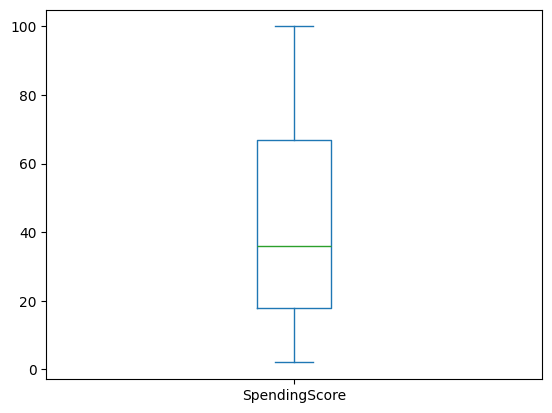

In [3]:
df['SpendingScore'].plot.box()

In [4]:
print(df.describe())

       AnnualIncome  SpendingScore
count     44.000000      44.000000
mean      29.090909      42.977273
std       16.388195      29.609465
min       15.000000       2.000000
25%       20.375000      17.750000
50%       25.750000      36.000000
75%       31.125000      66.750000
max       90.000000     100.000000


In [19]:
ind = df['AnnualIncome'].sort_values(ascending=False).index

In [22]:
ind

Index([43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26,
       25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,
        7,  6,  5,  4,  3,  2,  1,  0],
      dtype='int64')

In [ ]:

df.iloc[ind]

,AnnualIncome,SpendingScore
43,90.0,100
42,85.0,3
41,80.0,2
40,35.0,56
39,34.5,32
38,34.0,29
37,33.5,26
36,33.0,23
35,32.5,20
34,32.0,17


In [23]:
# Normalize the dataset using StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert the scaled data back into a DataFrame for easier handling
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)  
print(scaled_df.head())

   AnnualIncome  SpendingScore
0     -0.869761      -0.135877
1     -0.838899      -0.033387
2     -0.808036       0.069103
3     -0.777174       0.171594
4     -0.746311       0.274084


In [24]:
ind_2 = scaled_df['AnnualIncome'].sort_values(ascending=False).index

In [25]:
scaled_df.iloc[ind_2]

,AnnualIncome,SpendingScore
43,3.759613,1.948092
42,3.450988,-1.365761
41,3.142363,-1.399924
40,0.364739,0.444901
39,0.333876,-0.375021
38,0.303014,-0.477512
37,0.272151,-0.580002
36,0.241289,-0.682492
35,0.210426,-0.784983
34,0.179564,-0.887473


In [31]:
# Initialize the k means cluster with k clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit the model and assign cluster labels
kmeans.fit(scaled_df)
df['Cluster'] = kmeans.labels_

#Display the first few rows with cluster labels
print(df.head())

   AnnualIncome  SpendingScore  Cluster
0          15.0             39        2
1          15.5             42        2
2          16.0             45        2
3          16.5             48        2
4          17.0             51        2


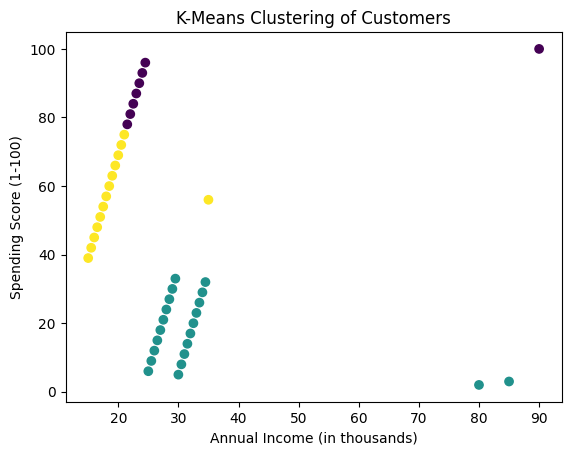

In [32]:
# Plot the clusters
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='viridis')
plt.title('K-Means Clustering of Customers')
plt.xlabel('Annual Income (in thousands)')
plt.ylabel('Spending Score (1-100)')
plt.show()

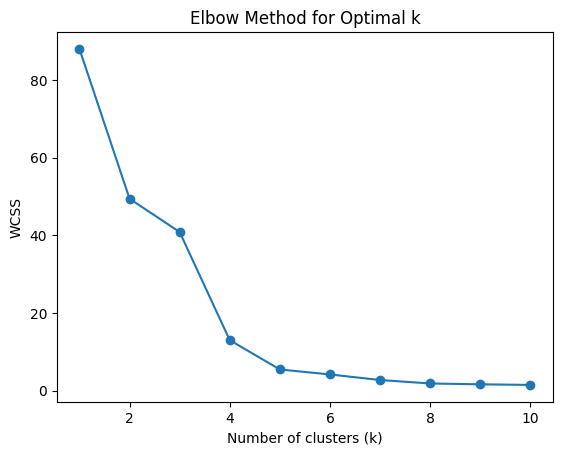

In [33]:
# Calculate the WCSS (Within-Cluster Sum of Squares) for different values of k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)
    
# Plot the WCS to find the elbow point
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')    
plt.ylabel('WCSS')
plt.show()

In [ ]:
#Needed more text